In [25]:
import utils
from PIL import Image
import matplotlib.pyplot as plt

model = utils.load_model()

layers = {
    "Shallow (layer1)": model.layer1,
    "Deep (layer4)": model.layer4,
}

print("Loaded model:", type(model).__name__)

Loaded model: ResNet


In [26]:
img_a = Image.open("assets/bicycle.jpg").convert("RGB")
img_b = Image.open("assets/dog.jpg").convert("RGB")

In [27]:
layer_name = "Shallow (layer1)"
# layer_name = "Deep (layer4)"
layer = layers[layer_name]
print("CAM layer:", layer_name)

CAM layer: Shallow (layer1)


In [28]:
def show_img(pil_img, title="", figsize=(4,4)):
    plt.figure(figsize=figsize)
    plt.imshow(pil_img)
    plt.axis("off")
    plt.title(title)
    plt.show()

In [29]:
def render_g_panel(pil_img, title="Image", topk=5, show_channel=0):
    x = utils.pil_to_tensor(pil_img)

    show_img(pil_img, f"{title}")

    preds = utils.predict_topk(model, x, k=topk)
    print(f"{title}: Top-{topk} predictions (class index, probability):")
    for cls_idx, prob in preds:
        print(f"  {cls_idx:4d}  {prob:.4f}")

    print(f"{title}: Grad-CAM on {layer_name}")
    try:
        cam_img = utils.gradcam_overlay(model, x, pil_img, layer)
        show_img(cam_img, f"{title}: Grad-CAM ({layer_name})")
    except Exception as e:
        print("Grad-CAM failed:", e)

    acts = utils.capture_activations(model, x, layers)
    for lname in layers.keys():
        act = acts[lname]
        print(f"{title}: {lname} activation shape:", tuple(act.shape))

        mean_img = utils.activation_mean(act).resize((224, 224))
        plt.figure(figsize=(4,4))
        plt.imshow(mean_img, cmap="gray")
        plt.axis("off")
        plt.title(f"{title}: {lname} mean activation")
        plt.show()

        ch = min(show_channel, act.shape[1] - 1)
        ch_img = utils.activation_channel(act, ch).resize((224, 224))
        plt.figure(figsize=(4,4))
        plt.imshow(ch_img, cmap="gray")
        plt.axis("off")
        plt.title(f"{title}: {lname} channel {ch}")
        plt.show()


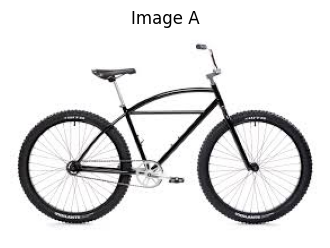

Image A: Top-5 predictions (class index, probability):
   671  0.8488
   444  0.1297
   880  0.0171
   870  0.0039
   665  0.0004
Image A: Grad-CAM on Shallow (layer1)


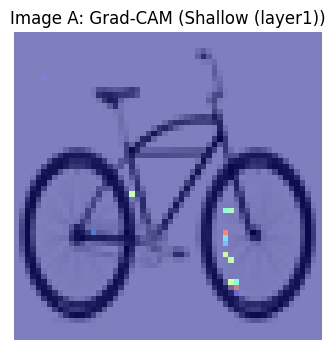

Image A: Shallow (layer1) activation shape: (1, 64, 56, 56)


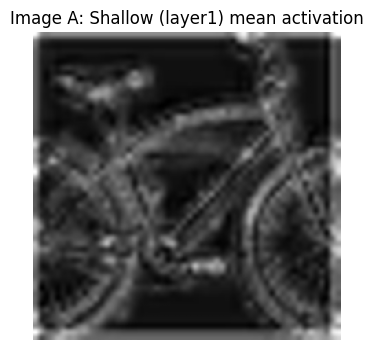

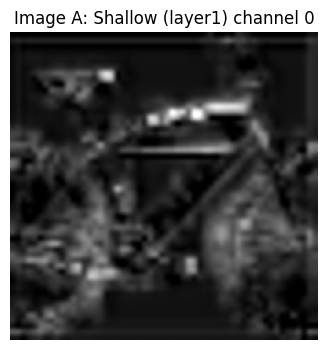

Image A: Deep (layer4) activation shape: (1, 512, 7, 7)


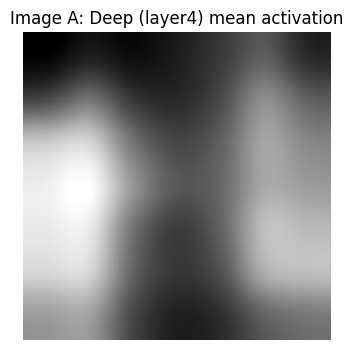

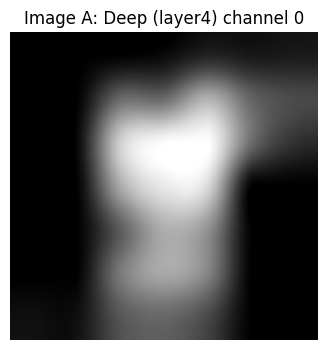

In [ ]:
# Try changing the values below to see how it affects the results:
render_g_panel(img_a, title="Image A", topk=5, show_channel=0)

---

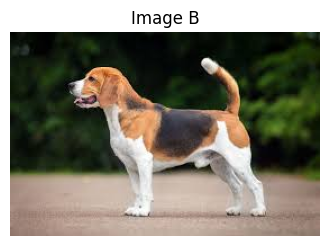

Image B: Top-5 predictions (class index, probability):
   167  0.8441
   166  0.1145
   162  0.0344
   161  0.0058
   163  0.0005
Image B: Grad-CAM on Shallow (layer1)


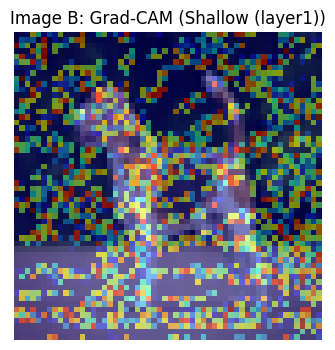

Image B: Shallow (layer1) activation shape: (1, 64, 56, 56)


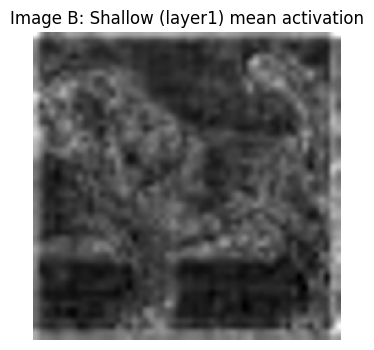

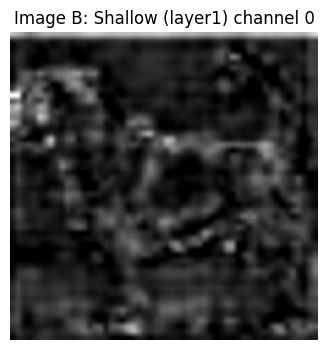

Image B: Deep (layer4) activation shape: (1, 512, 7, 7)


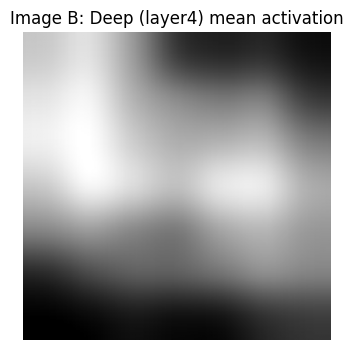

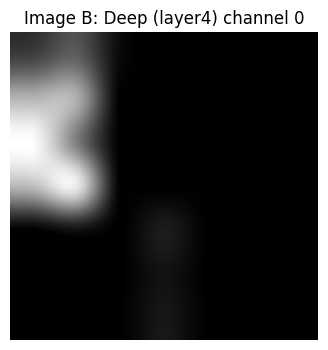

In [ ]:
render_g_panel(img_b, title="Image B", topk=5, show_channel=0)

---

### Metod

Jag använde en förtränad ResNet-18 från torchvision.
[(ResNet-18)](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html)

För att analysera hur nätverket bearbetar bilderna visualiserade jag aktiveringar från två olika lager:

- conv1 (tidigt lager)

- layer4 (djupt lager)

Aktiveringarna hämtades med *forward hooks*. Två bilder användes: en cykel och en hund.

### Motivation av lagret
**conv1** valdes eftersom det är första konvolutionslagret och förväntas fånga enkla mönster som kanter och kontraster.

**layer4** valdes eftersom det är det sista konvolutionsblocket före klassificering och därför bör innehålla mer abstrakta och klass-specifika representationer.

### Resultat

För båda bilderna syns det att:

I **conv1** är aktiveringarna relativt detaljerade och högupplösta. Flera kanaler markerar tydligt kanter och konturer. I cykelbilden framträder exempelvis hjulens runda former och ramen tydligt. I hundbilden syns hundens silhuett, ben och svans i olika kanaler. Aktiveringarna är relativt täta och reagerar på många delar av bilden.

I **layer4** är aktiveringarna betydligt mer glesa och har lägre rumslig upplösning. Endast vissa områden i bilden aktiveras tydligt medan stora delar förblir mörka. Detta tyder på att representationen är mer selektiv och fokuserar på mer abstrakta mönster som är relevanta för klassificeringen.